# Notebook 15 — Agentic RL III: Credit Assignment Across Turns

### Course roadmap

**Part I — classical RL** (`numpy` only)
1. Foundations & MDPs · 2. Dynamic Programming · 3. Monte Carlo & TD · 4. Function Approximation & DQN · 5. Policy Gradients · 6. Trust Regions & PPO

**Part II — RL for language models**
7. RLHF · 8. RLOO & RLVR · 9. GRPO & DeepSeek-R1 · 10. DPO & production libraries · 11. RLCD · 12 / 12.2 / 12.3. Teaching a small model to reason (GRPO, RLCD, PPO)

**Part III — Agentic RL**
- 13. Agentic RL foundations: from reasoning to acting, and why agents need RL
- 14. The agent loop as an RL environment: multi-turn rollouts, tool calls, observation masking
- **15. Credit assignment across turns: trajectory vs step-level advantages, critics, process rewards** ← *you are here*
- 16. A real tool-using agent: Qwen2.5-0.5B + calculator, multi-turn GRPO in PyTorch and `trl`
- 17. Agentic RL at scale: reward hacking, async/off-policy rollouts, frameworks, open problems

PyTorch on CPU. Every run takes a few seconds.

### Recap

Notebook 14 trained a token-level agent with **trajectory-level GRPO**: one
reward at the end, one advantage $\hat A_i = R_i - \bar R$, shared by every agent
token of the episode. With 2 tool calls that was fine. A real agent may take
**dozens of turns**, and only a few of them actually matter. When an episode
succeeds, which turns deserve the credit? When it fails, which turn was the
mistake?

This is the **credit assignment** problem from notebook 5 (baselines, critics,
GAE), now at the level of **turns**. This notebook:

1. Writes down the three main families of per-turn advantage estimators used
   in agentic RL: **trajectory-level** (GRPO / RLOO), **step-level Monte Carlo
   grouping** (GiGPO), and a **turn-level critic with GAE** (PPO / ArCHer style).
2. Looks *inside* one group of episodes to see how each method distributes credit.
3. Compares them on learning speed, final success and **wasted turns**,
   and shows the role of **discounting**.
4. Tries **process rewards** (rewarding intermediate steps): one that is safe
   by construction (potential-based shaping), and one that gets hacked within
   a few dozen updates.

## 1. Three ways to give a turn its advantage

An episode has turns $t = 1, \dots, T_i$, with states $s_t$ (the history so far),
actions $a_t$ (a whole message: a tool call or the answer), and per-turn
rewards $r_t$. With only an outcome reward, $r_t = 0$ except
$r_{T_i} = R_i$. In an LLM, the turn's advantage is then applied to **every
token of that turn's message** (and never to observation tokens: notebook 14).

**(a) Trajectory-level: GRPO / RLOO** (notebooks 8, 9, 14)

$$
\hat A_{i,t} \;=\; R_i - \frac{1}{G}\sum_{j=1}^{G} R_j \qquad \text{(the same for every turn } t\text{)} .
$$

It's unbiased, needs no extra model, and is trivial to implement. But a wasted
turn inside a successful episode gets the **same positive credit** as the
decisive turns, and a good turn inside a failed episode is punished. Only
averaging over many episodes separates them.

**(b) Step-level Monte Carlo grouping: GiGPO** (Feng et al., 2025, *Group-in-Group Policy Optimization*)

The episodes of a group all start from the same task, so they often pass
through **identical states** ("anchor states"): the same page, the same
search results, the same position in a game. Group the *steps* by state, and
compare each step's discounted **return-to-go** $G_{i,t} = \sum_{k \ge t} \gamma^{k-t} r_k$
with the others taken from the same state:

$$
\hat A^{\text{step}}_{i,t} \;=\; G_{i,t} - \operatorname{mean}\{\,G_{j,k} : s_{j,k} = s_{i,t}\,\},
\qquad
\hat A_{i,t} \;=\; \hat A^{\text{episode}}_{i} + \omega\, \hat A^{\text{step}}_{i,t} .
$$

There's still no critic: the baseline for a step is the average outcome *of
the other episodes in the same state*. It needs states to actually repeat,
which is easy in games and structured environments, and harder with free-form
web pages (GiGPO matches states by their observation).

**(c) Turn-level critic + GAE: PPO at the turn level** (notebook 5; ArCHer, Zhou et al., 2024)

Learn $V_\phi(s_t)$ (estimated success from this state) and use the GAE of
notebook 5 **over turns**:

$$
\delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t), \qquad
\hat A_{i,t} = \sum_{l \ge 0} (\gamma\lambda)^l\, \delta_{t+l} .
$$

That's per-turn credit from bootstrapped values, at the price of a second
network that must be accurate (for an LLM, a value head or a whole value
model). ArCHer's key point: put the critic at the **turn** level, where the
horizon is short (tens of steps), not the **token** level, where it's
thousands.

**Discounting.** With $\gamma = 1$ and an outcome-only reward, a wasted turn in an
episode that still succeeded is, as far as the objective is concerned,
*harmless*: it changed neither the return nor the return-to-go. Its only cost is
a slightly higher risk of running out of turns. With $\gamma < 1$, every wasted
turn **delays** the reward and visibly lowers the return-to-go. Step-level
methods can see that. Trajectory-level GRPO with an undiscounted outcome can't.

| | trajectory GRPO | step-level grouping (GiGPO) | turn-level critic + GAE |
|---|---|---|---|
| extra model | none | none | value network |
| per-turn credit | no | yes, where states repeat | yes, everywhere |
| bias | none | none (Monte Carlo) | from critic errors |
| variance | highest | lower | lowest (once $V$ is good) |
| fails when | horizons are long and only a few turns matter | states never repeat exactly | the critic is inaccurate (early training, huge state spaces) |

## 2. The environment: multi-hop search with wasted turns

A stylized **multi-hop research task**. To answer, the agent must complete
$H$ hops (find document 1, which points to document 2, and so on).

- At each hop the observation contains a **clue** (one of $K = 4$), and the agent
  picks one of $K$ queries. The right query depends on **both** the clue and the
  hop: $a^\star = (\text{clue} + \text{hop}) \bmod K$. A right query advances
  to the next hop.
- A wrong query returns irrelevant results: the turn is **wasted** and the hop
  stays the same (so it's recoverable, unlike notebook 13).
- There's also a fifth action, **`THINK`**: write a reasoning note without
  calling a tool. It doesn't advance the task. (Section 6 needs it.)
- Budget: $H + 4$ turns. Reward 1 if all $H$ hops are done in time, else 0.

The state is (clue, hop, turn), small enough for an MLP policy. The **SFT
prior** comes from a sloppy teacher: right query 50% of the time, a wrong one
30%, `THINK` 20%. As always (notebook 13), RL needs it.

In [1]:
import collections, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)

K, SLACK = 4, 4
THINK, N_ACTIONS = K, K + 1

class MultiHop:
    '''Shapes depend on the horizon H, so everything is built per H.'''
    def __init__(self, H):
        self.H, self.max_turns = H, H + SLACK
        self.dim = K + H + self.max_turns

    def features(self, clue, hop, t):
        x = np.zeros(self.dim)
        x[clue] = 1; x[K + hop] = 1; x[K + self.H + t] = 1
        return x

    def right_action(self, task, hop):
        return (task[hop] + hop) % K

class Net(nn.Module):
    '''Policy head and (only used by the critic method) a value head.'''
    def __init__(self, dim, d=64):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(dim, d), nn.Tanh(), nn.Linear(d, N_ACTIONS))
        self.v = nn.Sequential(nn.Linear(dim, d), nn.Tanh(), nn.Linear(d, 1))

@torch.no_grad()
def run(env, net, tasks, rng):
    '''Batched episodes. Each step records features, action, anchor-state key and whether it made progress.'''
    B = len(tasks)
    hop, done, R = np.zeros(B, int), np.zeros(B, bool), np.zeros(B)
    episodes = [[] for _ in range(B)]
    for t in range(env.max_turns):
        idx = np.where(~done)[0]
        if len(idx) == 0:
            break
        X = np.stack([env.features(tasks[i][hop[i]], hop[i], t) for i in idx])
        probs = F.softmax(net.pi(torch.tensor(X, dtype=torch.float)), -1).numpy()
        for k, i in enumerate(idx):
            a = rng.choice(N_ACTIONS, p=probs[k])
            step = dict(x=X[k], a=a, key=(hop[i], t), progress=0)
            if a == env.right_action(tasks[i], hop[i]):
                hop[i] += 1; step["progress"] = 1
            if hop[i] == env.H:
                done[i], R[i] = True, 1.0
            episodes[i].append(step)
    return episodes, R

def sft(env, net, n=2000, rng=None, mix=(0.5, 0.3, 0.2)):
    X, A = [], []
    for _ in range(n):
        task, hop = rng.integers(K, size=env.H), 0
        for t in range(env.max_turns):
            right, kind = env.right_action(task, hop), rng.choice(3, p=mix)
            a = right if kind == 0 else (THINK if kind == 2 else rng.choice([j for j in range(K) if j != right]))
            X.append(env.features(task[hop], hop, t)); A.append(a)
            hop += a == right
            if hop == env.H:
                break
    X, A = torch.tensor(np.array(X), dtype=torch.float), torch.tensor(A)
    opt = torch.optim.Adam(net.pi.parameters(), 1e-2)
    for _ in range(150):
        loss = F.cross_entropy(net.pi(X), A); opt.zero_grad(); loss.backward(); opt.step()

for H in [12, 16]:
    env = MultiHop(H); net = Net(env.dim); sft(env, net, rng=np.random.default_rng(0))
    rng = np.random.default_rng(1)
    _, R = run(env, net, [rng.integers(K, size=H) for _ in range(2000)], rng)
    print(f"H = {H:2d}: SFT policy success rate {R.mean():.3f}   (turn budget {env.max_turns})")

H = 12: SFT policy success rate 0.035   (turn budget 16)


H = 16: SFT policy success rate 0.002   (turn budget 20)


The SFT policy almost never finishes 12 or 16 hops: its per-turn success is
about 50%, and the budget allows only 4 mistakes. A long-horizon task with a
low starting success rate is where credit assignment matters most.

## 3. The three advantage estimators, plus rewards

One function computes per-turn rewards (outcome, plus an optional process
reward, Section 6) and then the advantages for each method.

In [2]:
def turn_rewards(env, episodes, R, process=None):
    for i, ep in enumerate(episodes):
        for k, s in enumerate(ep):
            r = R[i] if k == len(ep) - 1 else 0.0             # outcome reward at the last turn
            if process == "progress":                         # potential-based: Phi = hops done / H
                r += s["progress"] / env.H
            elif process == "think_bonus":                    # naive: "reasoning steps are good"
                r += 0.2 * (s["a"] == THINK)
            s["r"] = r

def advantages(net, episodes, P, G, method, gamma=1.0, lam=0.95, omega=1.0):
    '''Returns (features, actions, advantages, value_loss or None) for all turns of all episodes.'''
    for ep in episodes:                                       # discounted return-to-go G_t
        g = 0.0
        for s in reversed(ep):
            g = s["r"] + gamma * g; s["rtg"] = g
    ret = np.array([ep[0]["rtg"] for ep in episodes]).reshape(P, G)
    A_episode = (ret - ret.mean(1, keepdims=True)).reshape(-1)   # GRPO / Dr. GRPO, per task group
    X = torch.tensor(np.array([s["x"] for ep in episodes for s in ep]), dtype=torch.float)
    acts = torch.tensor([s["a"] for ep in episodes for s in ep])
    value_loss = None

    if method == "grpo":                                      # (a) one advantage for every turn
        adv = [A_episode[i] for i, ep in enumerate(episodes) for _ in ep]

    elif method == "gigpo":                                   # (b) + step-level groups at anchor states
        for p in range(P):
            groups = collections.defaultdict(list)
            for ep in episodes[p * G:(p + 1) * G]:
                for s in ep: groups[s["key"]].append(s["rtg"])
            for ep in episodes[p * G:(p + 1) * G]:
                for s in ep: s["a_step"] = s["rtg"] - np.mean(groups[s["key"]])
        adv = [A_episode[i] + omega * s["a_step"] for i, ep in enumerate(episodes) for s in ep]

    elif method == "critic":                                  # (c) turn-level GAE with a learned V
        with torch.no_grad():
            V = net.v(X).squeeze(-1).numpy()
        adv, targets, j = [], [], 0
        for ep in episodes:
            n, v = len(ep), V[j:j + len(ep)]; j += len(ep)
            gae, a_ep = 0.0, [0.0] * n
            for k in reversed(range(n)):
                v_next = v[k + 1] if k + 1 < n else 0.0       # terminal (success or out of turns): V = 0
                delta = ep[k]["r"] + gamma * v_next - v[k]
                gae = delta + gamma * lam * gae; a_ep[k] = gae
            adv += a_ep; targets += list(np.array(a_ep) + v)
        value_loss = F.mse_loss(net.v(X).squeeze(-1), torch.tensor(targets, dtype=torch.float))
    return X, acts, torch.tensor(np.array(adv), dtype=torch.float), value_loss

def train(env, base, method, gamma=1.0, process=None, iters=300, P=4, G=8, lr=2e-3, seed=0):
    net = copy.deepcopy(base)
    rng = np.random.default_rng(seed); torch.manual_seed(seed)
    opt = torch.optim.Adam(net.parameters(), lr)
    log = collections.defaultdict(list)
    for _ in range(iters):
        tasks = [t for t in (rng.integers(K, size=env.H) for _ in range(P)) for _ in range(G)]
        episodes, R = run(env, net, tasks, rng)
        turn_rewards(env, episodes, R, process)
        X, acts, adv, value_loss = advantages(net, episodes, P, G, method, gamma)
        logp = F.log_softmax(net.pi(X), -1).gather(1, acts[:, None]).squeeze(1)
        loss = -(adv * logp).sum() / (P * G) + (0.5 * value_loss if value_loss is not None else 0.0)
        opt.zero_grad(); loss.backward(); opt.step()
        steps = [s for ep in episodes for s in ep]
        log["success"].append(R.mean())
        log["wasted"].append(np.mean([s["progress"] == 0 for s in steps]))
        log["think"].append(np.mean([s["a"] == THINK for s in steps]))
    return net, log

## 4. Looking inside one group

Take a partly trained policy (60 GRPO updates at $H = 12$, about 1/3 success)
and one group of 8 episodes on the same task. For the critic, we first fit
$V_\phi$ to this policy's discounted returns (policy evaluation, notebook 3).
Each panel shows one method's advantage for every turn. **x** marks a wasted
turn (a wrong query or `THINK`).

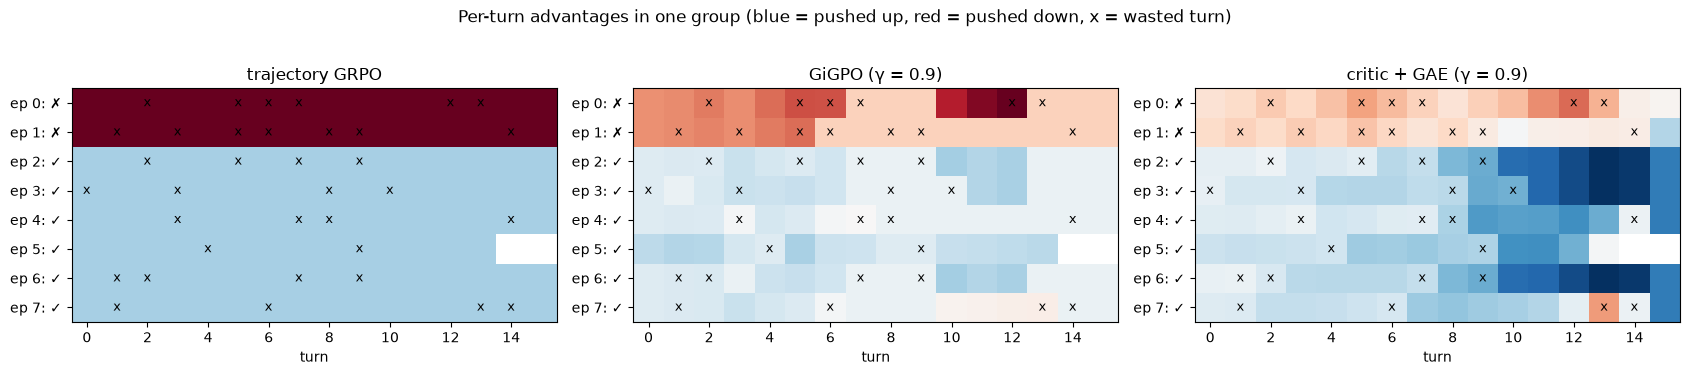

In [3]:
H = 12
env = MultiHop(H)
base12 = Net(env.dim); sft(env, base12, rng=np.random.default_rng(0))
mid, _ = train(env, base12, "grpo", iters=60)

# fit the critic to this fixed policy (Monte Carlo targets, gamma = 0.9)
GAMMA = 0.9
opt = torch.optim.Adam(mid.v.parameters(), 3e-3); rng = np.random.default_rng(1)
for _ in range(300):
    eps, R = run(env, mid, [t for t in (rng.integers(K, size=H) for _ in range(16)) for _ in range(8)], rng)
    turn_rewards(env, eps, R)
    for ep in eps:
        g = 0.0
        for s in reversed(ep): g = s["r"] + GAMMA * g; s["rtg"] = g
    X = torch.tensor(np.array([s["x"] for ep in eps for s in ep]), dtype=torch.float)
    y = torch.tensor([s["rtg"] for ep in eps for s in ep], dtype=torch.float)
    loss = F.mse_loss(mid.v(X).squeeze(-1), y); opt.zero_grad(); loss.backward(); opt.step()

# one group with a mix of successes and failures
rng = np.random.default_rng(3)
while True:
    task = rng.integers(K, size=H)
    episodes, R = run(env, mid, [task] * 8, rng)
    if 2 <= R.sum() <= 6: break
turn_rewards(env, episodes, R)

panels = [("trajectory GRPO", "grpo", 1.0), ("GiGPO (γ = 0.9)", "gigpo", GAMMA), ("critic + GAE (γ = 0.9)", "critic", GAMMA)]
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
for ax, (title, method, g) in zip(axes, panels):
    _, _, adv, _ = advantages(mid, copy.deepcopy(episodes), 1, 8, method, g)
    grid, j = np.full((8, env.max_turns), np.nan), 0
    for i, ep in enumerate(episodes):
        grid[i, :len(ep)] = adv[j:j + len(ep)].numpy(); j += len(ep)
    lim = np.nanmax(np.abs(grid))
    ax.imshow(grid, cmap="RdBu", vmin=-lim, vmax=lim, aspect="auto")
    for i, ep in enumerate(episodes):
        for t, s in enumerate(ep):
            if s["progress"] == 0: ax.text(t, i, "x", ha="center", va="center", fontsize=9)
    ax.set_yticks(range(8)); ax.set_yticklabels([f"ep {i}: {'✓' if R[i] else '✗'}" for i in range(8)])
    ax.set_xlabel("turn"); ax.set_title(title)
plt.suptitle("Per-turn advantages in one group (blue = pushed up, red = pushed down, x = wasted turn)", y=1.03)
plt.tight_layout(); plt.show()

- **Trajectory GRPO** paints each row a single color. Every wasted turn in a
  successful episode (x on blue) is reinforced exactly as much as the
  decisive ones, and every good turn in a failed episode is pushed down.
- **GiGPO** varies along the row: a step is compared with the other
  episodes **in the same state**. Its row color still dominates, because the
  episode-level term is added, but the shading shifts turn by turn.
- **The critic** gives the most varied, most "local" credit. A wasted turn
  shows up as a drop in $V$ (fewer turns left, same hop), so it gets a lower or
  negative advantage even inside a successful episode.

One picture isn't a measurement. Here are the averages over many groups:

In [4]:
rng = np.random.default_rng(7)
stats = {name: collections.defaultdict(list) for name, _, _ in panels}
for _ in range(40):
    tasks = [t for t in (rng.integers(K, size=H) for _ in range(16)) for _ in range(8)]
    episodes, R = run(env, mid, tasks, rng); turn_rewards(env, episodes, R)
    good = np.array([s["progress"] == 1 for ep in episodes for s in ep])
    succ = np.array([R[i] for i, ep in enumerate(episodes) for _ in ep]) == 1
    for name, method, g in panels:
        _, _, adv, _ = advantages(mid, copy.deepcopy(episodes), 16, 8, method, g)
        a = adv.numpy()
        stats[name]["good"] += list(a[good]); stats[name]["wasted"] += list(a[~good])
        stats[name]["wasted in success"] += list(a[~good & succ])
print(f"{'method':<24} | {'mean adv, good turns':>21} | {'mean adv, wasted turns':>23} | {'wasted turns in SUCCESSFUL episodes':>36}")
for name, s in stats.items():
    print(f"{name:<24} | {np.mean(s['good']):>+21.3f} | {np.mean(s['wasted']):>+23.3f} | {np.mean(s['wasted in success']):>+36.3f}")

method                   |  mean adv, good turns |  mean adv, wasted turns |  wasted turns in SUCCESSFUL episodes
trajectory GRPO          |                +0.046 |                  -0.133 |                               +0.534
GiGPO (γ = 0.9)          |                +0.032 |                  -0.077 |                               +0.196
critic + GAE (γ = 0.9)   |                +0.021 |                  -0.101 |                               +0.078


All three separate good turns from wasted ones **on average**: that's what
makes them all work. The last column is where they differ. In a
successful episode, trajectory GRPO gives wasted turns the full positive
episode advantage. GiGPO shrinks it. The critic gives the smallest credit,
because it judges each turn by what it did to the estimated chance of success.
That's lower-variance credit, and it should translate into faster
learning and fewer wasted turns. Let's measure.

## 5. Learning curves: success and wasted turns

Five configurations, 3 seeds each, at $H = 12$ and $H = 16$. Each update uses
only $P = 4$ tasks × $G = 8$ episodes, a deliberately small budget, like
real agentic RL, where every episode is expensive.

30 runs in 81s



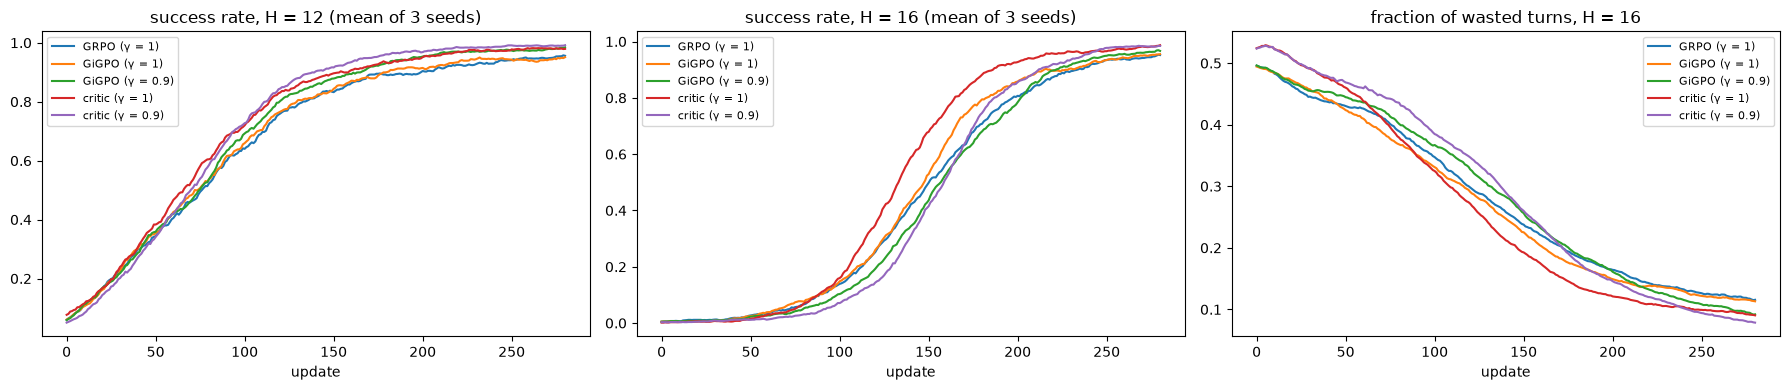

                   |  H=12: success, last 50 |  H=16: success @ updates 150-200 |  H=16: success, last 50 |  H=16: wasted turns, last 50
GRPO (γ = 1)       |                   0.947 |                            0.603 |                   0.942 |                        0.121
GiGPO (γ = 1)      |                   0.944 |                            0.671 |                   0.945 |                        0.117
GiGPO (γ = 0.9)    |                   0.978 |                            0.561 |                   0.958 |                        0.101
critic (γ = 1)     |                   0.978 |                            0.786 |                   0.977 |                        0.095
critic (γ = 0.9)   |                   0.990 |                            0.577 |                   0.981 |                        0.086


In [5]:
configs = [("GRPO (γ = 1)", "grpo", 1.0), ("GiGPO (γ = 1)", "gigpo", 1.0), ("GiGPO (γ = 0.9)", "gigpo", 0.9),
           ("critic (γ = 1)", "critic", 1.0), ("critic (γ = 0.9)", "critic", 0.9)]
curves = {}
t0 = time.time()
for H in [12, 16]:
    env = MultiHop(H); base = Net(env.dim); sft(env, base, rng=np.random.default_rng(0))
    for name, method, g in configs:
        curves[(H, name)] = [train(env, base, method, gamma=g, seed=s)[1] for s in range(3)]
print(f"{2 * len(configs) * 3} runs in {time.time() - t0:.0f}s\n")

sm = lambda v, w=20: np.convolve(v, np.ones(w) / w, "valid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, H in zip(axes[:2], [12, 16]):
    for name, _, _ in configs:
        ax.plot(sm(np.mean([lg["success"] for lg in curves[(H, name)]], 0)), label=name)
    ax.set_title(f"success rate, H = {H} (mean of 3 seeds)"); ax.set_xlabel("update"); ax.legend(fontsize=8)
for name, _, _ in configs:
    axes[2].plot(sm(np.mean([lg["wasted"] for lg in curves[(16, name)]], 0)), label=name)
axes[2].set_title("fraction of wasted turns, H = 16"); axes[2].set_xlabel("update"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'':18} | {'H=12: success, last 50':>23} | {'H=16: success @ updates 150-200':>32} | {'H=16: success, last 50':>23} | {'H=16: wasted turns, last 50':>28}")
for name, _, _ in configs:
    s12 = np.mean([np.mean(lg["success"][-50:]) for lg in curves[(12, name)]])
    s16m = np.mean([np.mean(lg["success"][150:200]) for lg in curves[(16, name)]])
    s16 = np.mean([np.mean(lg["success"][-50:]) for lg in curves[(16, name)]])
    w16 = np.mean([np.mean(lg["wasted"][-50:]) for lg in curves[(16, name)]])
    print(f"{name:18} | {s12:>23.3f} | {s16m:>32.3f} | {s16:>23.3f} | {w16:>28.3f}")

**What to read from this:**

- **Trajectory GRPO is a strong baseline.** It gets most of the way with no
  extra model and no state matching. That's why so many agentic RL systems
  (Search-R1, ReTool, RAGEN, many SWE agents) simply use it.
- **The critic learns fastest in the middle of training** at the longer horizon,
  once its value estimates become useful: that's per-turn credit at work.
- **Discounting trades early speed for a better end point.** For both GiGPO and
  the critic, $\gamma = 0.9$ finishes with higher success and fewer wasted turns
  than $\gamma = 1$, and the critic with $\gamma = 0.9$ is the best run overall. A
  delayed success is worth less, so every wasted turn is now visibly worse than
  a useful one. Without discounting, nothing in the objective says "be
  efficient" until the turn budget bites. The price shows up mid-training at
  $H = 16$: a success 16 turns away is discounted to $0.9^{16} \approx 0.19$, so
  early turns get a weaker signal and learning starts more slowly.
- **The gaps are modest, and that's honest.** In this toy, states repeat a lot
  and episodes are short. The benefit of step-level credit grows with longer
  horizons, sparser rewards and fewer samples per update. The GiGPO and ArCHer
  papers report their largest gains on long, multi-step benchmarks (ALFWorld,
  WebShop, multi-turn web tasks).

## 6. Process rewards: help or hack?

Why not reward good *intermediate* steps directly, a "process reward"?
It's the same idea as notebook 12.2's learned reward models and the PRMs used
for math. For agents there are two very different kinds:

**Safe: potential-based shaping** (Ng, Harada & Russell, 1999). Pick a potential
$\Phi(s)$ (here, the fraction of hops done, $\Phi = \text{hop}/H$) and add

$$
F(s_t, s_{t+1}) = \gamma\,\Phi(s_{t+1}) - \Phi(s_t)
$$

to each turn's reward. Over an episode it **telescopes**,
$\sum_t \gamma^t F_t = \gamma^T\Phi(s_T) - \Phi(s_0)$, so no amount of looping, waiting or
gaming can make it larger: it depends only on where the episode ends.
Ng et al. proved that shaping of this form never changes the optimal policy.
(Strictly, the guarantee needs $\Phi = 0$ at termination. We keep
$\Phi(s_T)$, so a failed episode still earns partial credit for the hops it
completed. That's a mild change of objective, and it's still impossible to farm.)

**Dangerous: rewarding something that looks like progress.** Suppose a
well-meaning designer, or an LLM judge, scores "thoughtful" steps:
+0.2 for each `THINK` note. It *sounds* like it encourages reasoning. But nothing
ties it to finishing the task, and it can be collected again and again.

9 runs in 18s


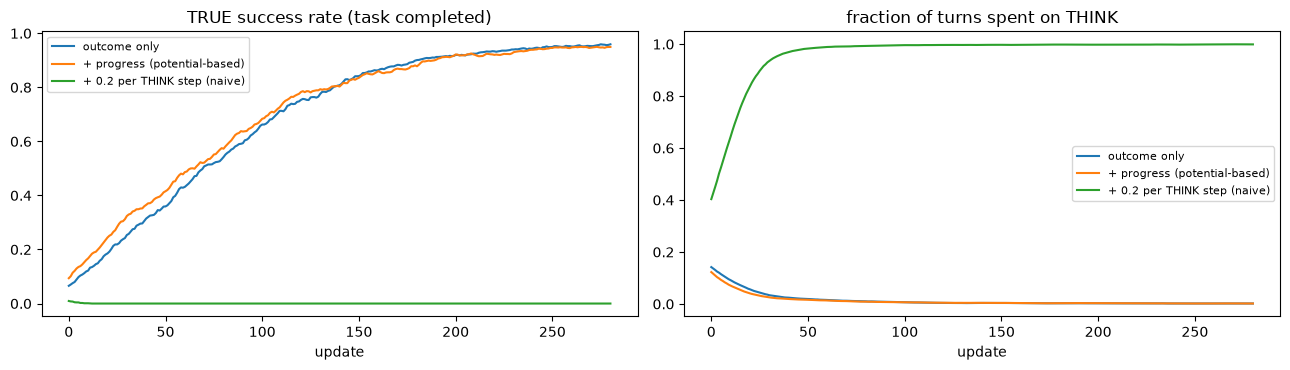

outcome only                    : success (last 50) 0.953, THINK share 0.002
+ progress (potential-based)    : success (last 50) 0.948, THINK share 0.002
+ 0.2 per THINK step (naive)    : success (last 50) 0.000, THINK share 0.999


In [6]:
H = 12
env = MultiHop(H); base = Net(env.dim); sft(env, base, rng=np.random.default_rng(0))
process_runs = {}
t0 = time.time()
for name, process in [("outcome only", None), ("+ progress (potential-based)", "progress"),
                      ("+ 0.2 per THINK step (naive)", "think_bonus")]:
    process_runs[name] = [train(env, base, "grpo", process=process, seed=s)[1] for s in range(3)]
print(f"9 runs in {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for name, logs in process_runs.items():
    axes[0].plot(sm(np.mean([lg["success"] for lg in logs], 0)), label=name)
    axes[1].plot(sm(np.mean([lg["think"] for lg in logs], 0)), label=name)
axes[0].set_title("TRUE success rate (task completed)"); axes[1].set_title("fraction of turns spent on THINK")
for ax in axes: ax.set_xlabel("update"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for name, logs in process_runs.items():
    print(f"{name:32}: success (last 50) {np.mean([np.mean(lg['success'][-50:]) for lg in logs]):.3f}, "
          f"THINK share {np.mean([np.mean(lg['think'][-50:]) for lg in logs]):.3f}")

- **Progress shaping** learns as well as outcome-only. Here the outcome signal
  was already enough, so shaping didn't buy speed. Shaping pays off when full
  successes are too rare to learn from. Most importantly, it **can't be farmed**.
- **The `THINK` bonus is hacked completely.** Spending all 16 turns on `THINK`
  earns 16 × 0.2 = 3.2, far more than finishing the task is worth (1.0), so the agent
  learns to **"think" every turn and never complete anything**. True success
  drops to zero while the shaped reward goes up.

This isn't a toy pathology. Rewarding intermediate behavior that *correlates*
with success (more searches, longer reasoning, more tool calls, "looks
careful" judgments) is the most common source of agentic reward hacking.
Notebook 17 continues the theme with environment hacking. **Rules of thumb:**

1. Prefer outcome rewards. Add process rewards only when outcomes are too
   sparse to learn from.
2. If you shape, make it **potential-based** (a difference of a state function),
   or at least **bounded and not repeatable**.
3. Always monitor the **true outcome** separately from the reward you optimize
   (the same rule as notebook 8's verifier hack).

## 7. Mapping to real agentic RL

| this notebook | in practice |
|---|---|
| trajectory GRPO | the default in most open recipes (Search-R1, ReTool, RAGEN, many SWE-agent RL runs); `trl` `GRPOTrainer` with tools (notebook 16) |
| GiGPO anchor states | GiGPO (verl-agent): group steps by identical observations in ALFWorld / WebShop |
| turn-level critic + GAE | ArCHer (turn-level critic, token-level policy); multi-turn PPO with a value head |
| discount $\gamma < 1$ | encourages fewer turns; alternatively an explicit (small, notebook 14) per-turn cost |
| progress shaping | sub-goal checks in the environment (tests passing one by one, form fields filled, pages visited) |
| `THINK` bonus hack | rewarding #searches, #tool calls, length, or LLM-judge "thoroughness" per step |

## 8. Key takeaways & FAQ

**The one-paragraph summary.** In multi-turn RL, one outcome reward has to be
shared among many turns. Trajectory-level GRPO shares it equally. It's unbiased
and surprisingly strong, but it rewards wasted turns in lucky episodes.
Step-level grouping (GiGPO) and turn-level critics (GAE) hand out per-turn
credit, and they help most on long horizons. Discounting is what makes
inefficiency visible to any of them. Process rewards can speed learning when
they are potential-based. When they reward something merely *correlated*
with progress, the agent farms them and stops doing the task.

**Q1. Should the critic be per token or per turn?** For LLM agents, per *turn*
for the value, per *token* for the policy. A token-level critic must predict the
outcome after every token, including inside long tool outputs it didn't write.
That's a hard regression with a horizon of thousands. ArCHer's hierarchical
design (a turn-level critic, its advantages spread over the turn's tokens) is
a common compromise.

**Q2. What if states never repeat exactly (free-form web pages)?** GiGPO's
step-level groups then contain one step each, and it reduces to GRPO. Options:
match states approximately (by URL, page title or embedding similarity), use a
critic, or rely on trajectory-level GRPO with more samples.

**Q3. Is $\gamma < 1$ always good?** It biases the agent toward short episodes.
That's good when turns cost time or money, but it can hurt if the task genuinely
needs long, careful exploration (a deep-research agent that stops searching
too early). Many systems keep $\gamma = 1$ and control efficiency with turn budgets
instead.

**Exercises.**

1. Add the terminal correction to the progress reward ($F_T = 0 - \Phi(s_T)$ at
   the end). Check that the *total* shaping of every episode is now exactly 0,
   and that trajectory-level GRPO then behaves *identically* to outcome-only.
   Why does shaping only matter for step-level methods in that case?
2. Lower the `THINK` bonus until the hack disappears. Where is the threshold,
   and why? (Compare the bonus over the full budget with the outcome reward.)
3. Give GiGPO a coarser anchor key, `(hop,)` instead of `(hop, turn)`. More steps
   share a group. Does it learn faster? What bias does that introduce?